# Logistic Regression: Newton-Type Methods Study

This notebook is kept compact and uses the implementations in `code.py` and `Z_project.py`.

It covers:
1. Real-data comparison on Spambase
2. Loss vs iteration and loss vs time
3. Final summary of loss, runtime, accuracy
4. Line search effect
5. Sketch size tradeoff
6. Hessian step quality
7. Synthetic conditioning study
8. Preconditioning study
9. Compact report notes


In [1]:
import os
import pathlib
import importlib.util
import numpy as np
os.environ['MPLCONFIGDIR']='/tmp/matplotlib'
import matplotlib.pyplot as plt

base_path=pathlib.Path.cwd()
code_path=base_path/'code.py'
spec=importlib.util.spec_from_file_location('project_code',code_path)
project_code=importlib.util.module_from_spec(spec)
spec.loader.exec_module(project_code)

load_spambase=project_code.load_spambase
loss=project_code.loss
gradient=project_code.gradient
gradient_descent=project_code.gradient_descent
hessian_vector_product=project_code.hessian_vector_product
hessian_diagonal=project_code.hessian_diagonal

from Z_project import hessian,newton_method,newton_cg,newton_pcg
from Z_project import gaussian_sketch,sketched_newton,sketched_conjugate_gradient

plt.rcParams['figure.figsize']=(7,4)
plt.rcParams['axes.grid']=True
plt.rcParams['grid.alpha']=0.25
np.random.seed(0)

In [2]:
def accuracy(X,y,w):
    pred=np.sign(np.sum(X*w,axis=1))
    pred[pred==0]=1
    return np.mean(pred==y)

def run_real_data(iters_gd=100,iters_newton=12,lam=1e-4):
    X,y=load_spambase()
    w0=np.zeros(X.shape[1])
    out={}
    out['X']=X
    out['y']=y

    losses,w,times=gradient_descent(X,y,w0.copy(),lr=0.1,iters=iters_gd,lam=lam)
    out['gd']={'losses':losses,'times':times,'w':w}

    losses,w,times=newton_method(X,y,w0.copy(),iters=iters_newton,lam=lam,use_line_search=True)
    out['newton']={'losses':losses,'times':times,'w':w}

    losses,w,times,cg_steps=newton_cg(X,y,w0.copy(),iters=iters_newton,lam=lam,use_line_search=True)
    out['newton_cg']={'losses':losses,'times':times,'cg_steps':cg_steps,'w':w}

    losses,w,times,cg_steps=newton_pcg(X,y,w0.copy(),iters=iters_newton,lam=lam,use_line_search=True)
    out['newton_pcg']={'losses':losses,'times':times,'cg_steps':cg_steps,'w':w}
    return out

def print_summary(res):
    X,y=res['X'],res['y']
    for name in ['gd','newton','newton_cg','newton_pcg']:
        f=res[name]['losses'][-1]
        t=res[name]['times'][-1]
        acc=accuracy(X,y,res[name]['w'])
        print(name,'loss=',round(f,6),'time=',round(t,4),'acc=',round(acc,4))

## 1. Real-data comparison on Spambase

In [3]:
real_res=run_real_data()
print_summary(real_res)

gd loss= 0.298669 time= 0.0528 acc= 0.9161
newton loss= 0.230027 time= 0.0432 acc= 0.925
newton_cg loss= 0.230036 time= 0.095 acc= 0.925
newton_pcg loss= 0.230027 time= 0.1012 acc= 0.925


## 2. Loss plots

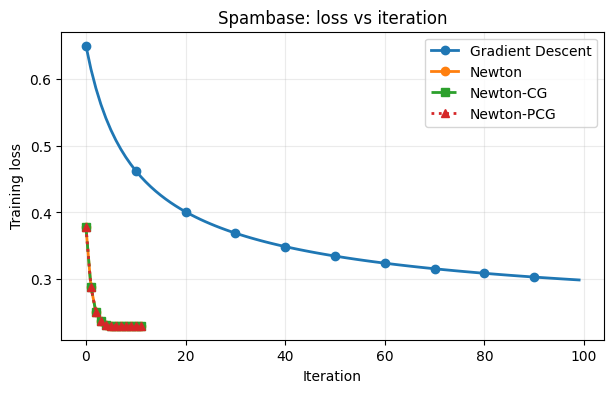

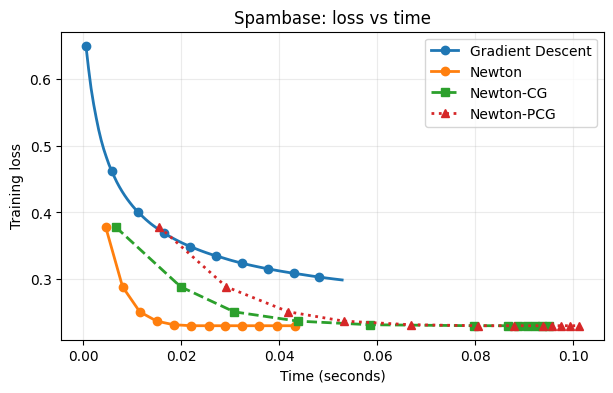

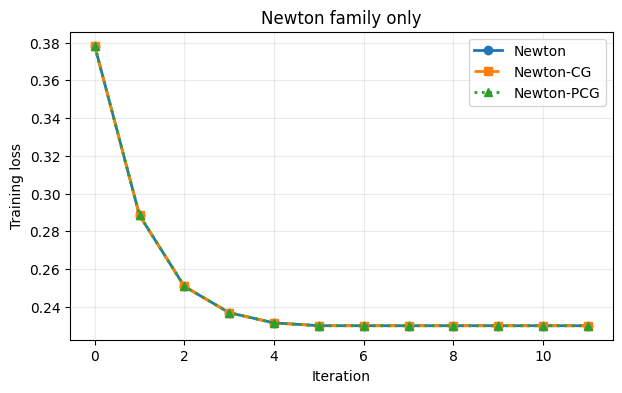

Newton losses: [0.378309 0.288482 0.250851 0.23694  0.231512 0.230048 0.230027 0.230027
 0.230027 0.230027 0.230027 0.230027]
Newton-CG losses: [0.378305 0.288484 0.250852 0.236938 0.231497 0.230049 0.230036 0.230036
 0.230036 0.230036 0.230036 0.230036]
Newton-PCG losses: [0.378309 0.288482 0.250851 0.23694  0.231512 0.230048 0.230027 0.230027
 0.230027 0.230027 0.230027 0.230027]


In [4]:
plt.figure()
plt.plot(real_res['gd']['losses'],label='Gradient Descent',lw=2,marker='o',markevery=10)
plt.plot(real_res['newton']['losses'],label='Newton',lw=2,marker='o')
plt.plot(real_res['newton_cg']['losses'],label='Newton-CG',lw=2,marker='s',ls='--')
plt.plot(real_res['newton_pcg']['losses'],label='Newton-PCG',lw=2,marker='^',ls=':')
plt.xlabel('Iteration')
plt.ylabel('Training loss')
plt.title('Spambase: loss vs iteration')
plt.legend()
plt.show()

plt.figure()
plt.plot(real_res['gd']['times'],real_res['gd']['losses'],label='Gradient Descent',lw=2,marker='o',markevery=10)
plt.plot(real_res['newton']['times'],real_res['newton']['losses'],label='Newton',lw=2,marker='o')
plt.plot(real_res['newton_cg']['times'],real_res['newton_cg']['losses'],label='Newton-CG',lw=2,marker='s',ls='--')
plt.plot(real_res['newton_pcg']['times'],real_res['newton_pcg']['losses'],label='Newton-PCG',lw=2,marker='^',ls=':')
plt.xlabel('Time (seconds)')
plt.ylabel('Training loss')
plt.title('Spambase: loss vs time')
plt.legend()
plt.show()

plt.figure()
plt.plot(real_res['newton']['losses'],label='Newton',lw=2,marker='o')
plt.plot(real_res['newton_cg']['losses'],label='Newton-CG',lw=2,marker='s',ls='--')
plt.plot(real_res['newton_pcg']['losses'],label='Newton-PCG',lw=2,marker='^',ls=':')
plt.xlabel('Iteration')
plt.ylabel('Training loss')
plt.title('Newton family only')
plt.legend()
plt.show()

print('Newton losses:',np.round(real_res['newton']['losses'],6))
print('Newton-CG losses:',np.round(real_res['newton_cg']['losses'],6))
print('Newton-PCG losses:',np.round(real_res['newton_pcg']['losses'],6))

## 3. Final summary

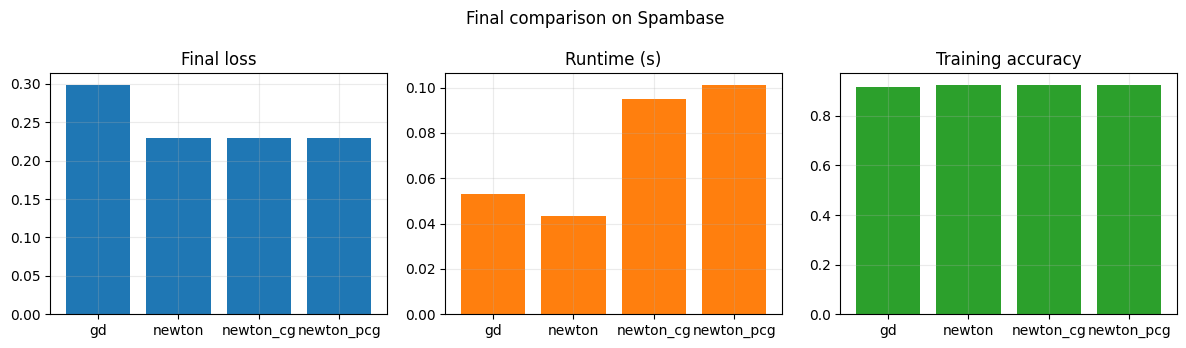

gd loss= 0.298669 time= 0.0528 accuracy= 0.9161
newton loss= 0.230027 time= 0.0432 accuracy= 0.925
newton_cg loss= 0.230036 time= 0.095 accuracy= 0.925
newton_pcg loss= 0.230027 time= 0.1012 accuracy= 0.925


In [5]:
X,y=real_res['X'],real_res['y']
names=['gd','newton','newton_cg','newton_pcg']
final_loss=[]
final_time=[]
final_acc=[]

for name in names:
    final_loss.append(real_res[name]['losses'][-1])
    final_time.append(real_res[name]['times'][-1])
    final_acc.append(accuracy(X,y,real_res[name]['w']))

x=np.arange(len(names))
fig,axes=plt.subplots(1,3,figsize=(12,3.5))
axes[0].bar(x,final_loss,color='tab:blue')
axes[0].set_xticks(x,names)
axes[0].set_title('Final loss')
axes[1].bar(x,final_time,color='tab:orange')
axes[1].set_xticks(x,names)
axes[1].set_title('Runtime (s)')
axes[2].bar(x,final_acc,color='tab:green')
axes[2].set_xticks(x,names)
axes[2].set_title('Training accuracy')
plt.suptitle('Final comparison on Spambase')
plt.tight_layout()
plt.show()

for i,name in enumerate(names):
    print(name,'loss=',round(final_loss[i],6),'time=',round(final_time[i],4),'accuracy=',round(final_acc[i],4))

## 4. Line search effect

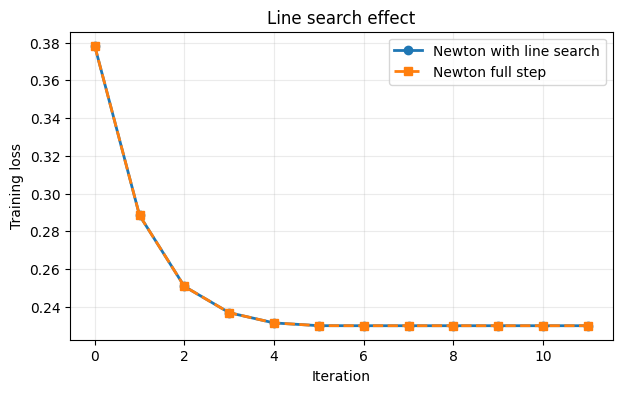

with line search: 0.23002670746778153
full step: 0.2300267074677816
These curves overlap on Spambase because the full Newton step is already stable here.


In [6]:
X,y=load_spambase()
w0=np.zeros(X.shape[1])
loss_ls,w_ls,time_ls=newton_method(X,y,w0.copy(),iters=12,use_line_search=True)
loss_full,w_full,time_full=newton_method(X,y,w0.copy(),iters=12,use_line_search=False)

plt.figure()
plt.plot(loss_ls,label='Newton with line search',lw=2,marker='o')
plt.plot(loss_full,label='Newton full step',lw=2,marker='s',ls='--')
plt.xlabel('Iteration')
plt.ylabel('Training loss')
plt.title('Line search effect')
plt.legend()
plt.show()

print('with line search:',loss_ls[-1])
print('full step:',loss_full[-1])
print('These curves overlap on Spambase because the full Newton step is already stable here.')

## 5. Sketch size tradeoff

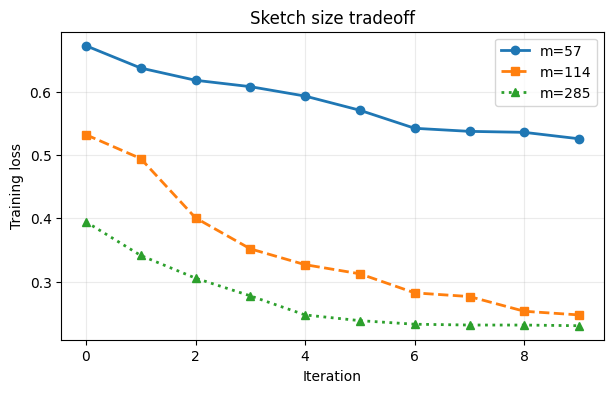

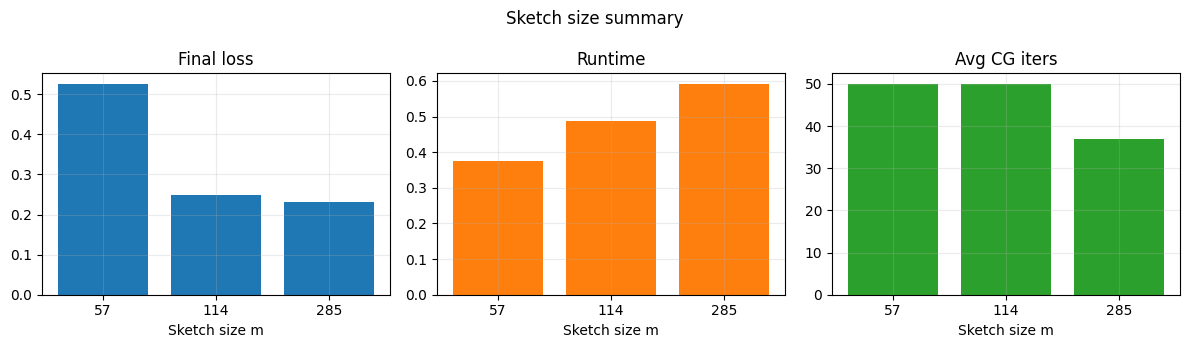

Sketch size table
m final_loss runtime avg_cg_iters
57 0.525734 0.3762 50.0
114 0.247426 0.4872 50.0
285 0.230373 0.5918 36.9


In [7]:
X,y=load_spambase()
w0=np.zeros(X.shape[1])
d=X.shape[1]
sizes=[d,2*d,5*d]
sketch_res={}

for m in sizes:
    losses,w,times,cg_steps=sketched_newton(X,y,w0.copy(),m,iters=10,use_line_search=True)
    sketch_res[m]={'losses':losses,'times':times,'cg_steps':cg_steps,'w':w}

plt.figure()
marks=['o','s','^']
styles=['-','--',':']
for i,m in enumerate(sizes):
    plt.plot(sketch_res[m]['losses'],label=f'm={m}',lw=2,marker=marks[i],ls=styles[i])
plt.xlabel('Iteration')
plt.ylabel('Training loss')
plt.title('Sketch size tradeoff')
plt.legend()
plt.show()

sketch_loss=[]
sketch_time=[]
sketch_cg=[]
for m in sizes:
    sketch_loss.append(sketch_res[m]['losses'][-1])
    sketch_time.append(sketch_res[m]['times'][-1])
    sketch_cg.append(np.mean(sketch_res[m]['cg_steps']))

fig,axes=plt.subplots(1,3,figsize=(12,3.5))
axes[0].bar([str(m) for m in sizes],sketch_loss,color='tab:blue')
axes[0].set_title('Final loss')
axes[0].set_xlabel('Sketch size m')
axes[1].bar([str(m) for m in sizes],sketch_time,color='tab:orange')
axes[1].set_title('Runtime')
axes[1].set_xlabel('Sketch size m')
axes[2].bar([str(m) for m in sizes],sketch_cg,color='tab:green')
axes[2].set_title('Avg CG iters')
axes[2].set_xlabel('Sketch size m')
plt.suptitle('Sketch size summary')
plt.tight_layout()
plt.show()

print('Sketch size table')
print('m final_loss runtime avg_cg_iters')
for i,m in enumerate(sizes):
    print(m,round(sketch_loss[i],6),round(sketch_time[i],4),round(sketch_cg[i],2))

## 6. Hessian step quality

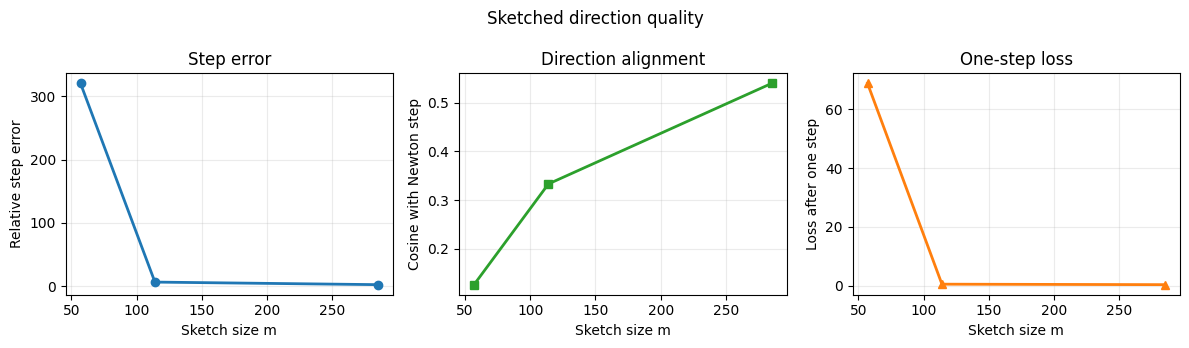

Hessian step quality table
m relative_error cosine one_step_loss
57 320.538 0.1266 68.77503
114 6.2778 0.3331 0.537994
285 2.2198 0.5392 0.375028


In [8]:
def step_quality(X,y,w,m,tries=4,lam=1e-4):
    g=gradient(X,y,w,lam)
    H=hessian(X,y,w,lam)
    p=np.linalg.solve(H,g)
    errs=[]
    angs=[]
    vals=[]
    for seed in range(tries):
        np.random.seed(seed)
        S=gaussian_sketch(len(y),m)
        q,_=sketched_conjugate_gradient(X,y,w,g,S,lam=lam,tol=1e-6,max_iters=40)
        err=np.linalg.norm(p-q)/(np.linalg.norm(p)+1e-9)
        cos=np.dot(p,q)/((np.linalg.norm(p)*np.linalg.norm(q))+1e-9)
        vals.append(loss(X,y,w-q,lam))
        errs.append(err)
        angs.append(cos)
    return np.mean(errs),np.mean(angs),np.mean(vals)

X,y=load_spambase()
w0=np.zeros(X.shape[1])
sizes=[X.shape[1],2*X.shape[1],5*X.shape[1]]
err_list=[]
cos_list=[]
step_loss=[]

for m in sizes:
    err,cos,val=step_quality(X,y,w0,m)
    err_list.append(err)
    cos_list.append(cos)
    step_loss.append(val)

fig,axes=plt.subplots(1,3,figsize=(12,3.5))
axes[0].plot(sizes,err_list,marker='o',lw=2)
axes[0].set_xlabel('Sketch size m')
axes[0].set_ylabel('Relative step error')
axes[0].set_title('Step error')
axes[1].plot(sizes,cos_list,marker='s',lw=2,color='tab:green')
axes[1].set_xlabel('Sketch size m')
axes[1].set_ylabel('Cosine with Newton step')
axes[1].set_title('Direction alignment')
axes[2].plot(sizes,step_loss,marker='^',lw=2,color='tab:orange')
axes[2].set_xlabel('Sketch size m')
axes[2].set_ylabel('Loss after one step')
axes[2].set_title('One-step loss')
plt.suptitle('Sketched direction quality')
plt.tight_layout()
plt.show()

print('Hessian step quality table')
print('m relative_error cosine one_step_loss')
for i,m in enumerate(sizes):
    print(m,round(err_list[i],4),round(cos_list[i],4),round(step_loss[i],6))

## 7. Synthetic conditioning study

/var/folders/xx/t73hkxhx7xj95d9rl4spgtb00000gn/T/ipykernel_36347/2690877488.py:6: RuntimeWarning: divide by zero encountered in matmul
  X=Z@(Q*s)
/var/folders/xx/t73hkxhx7xj95d9rl4spgtb00000gn/T/ipykernel_36347/2690877488.py:6: RuntimeWarning: overflow encountered in matmul
  X=Z@(Q*s)
/var/folders/xx/t73hkxhx7xj95d9rl4spgtb00000gn/T/ipykernel_36347/2690877488.py:6: RuntimeWarning: invalid value encountered in matmul
  X=Z@(Q*s)


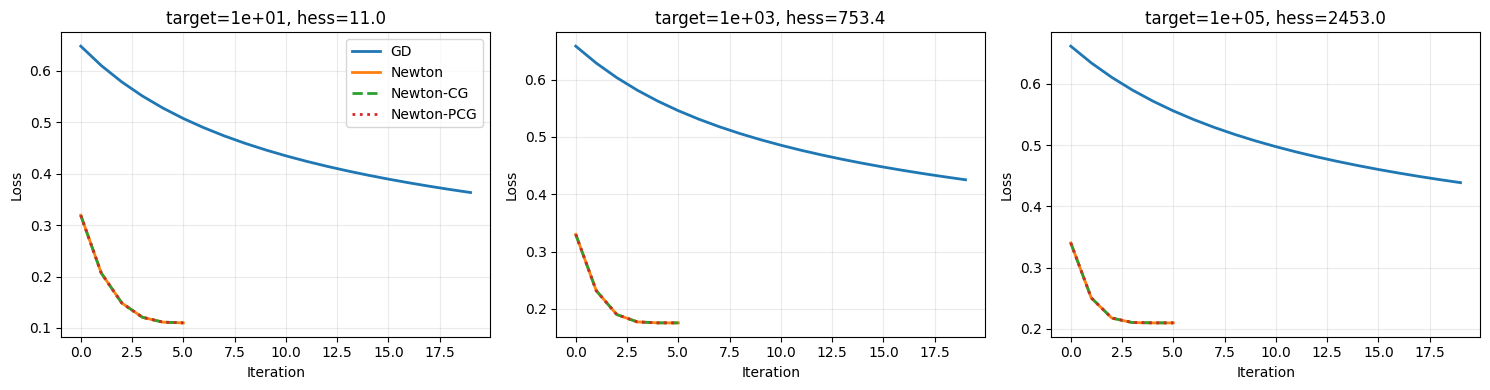

In [9]:
def make_synthetic(n=2500,d=40,cond_num=1e3,seed=0):
    rng=np.random.default_rng(seed)
    Z=rng.standard_normal((n,d))
    Q,_=np.linalg.qr(rng.standard_normal((d,d)))
    s=np.geomspace(1.0,cond_num**-0.5,d)
    X=Z@(Q*s)
    w_true=rng.standard_normal(d)/np.sqrt(d)
    score=np.sum(X*w_true,axis=1)+0.1*rng.standard_normal(n)
    y=np.where(score>=0,1.0,-1.0)
    return X,y

def run_synthetic(cond_num):
    X,y=make_synthetic(cond_num=cond_num,seed=1)
    w0=np.zeros(X.shape[1])
    H=hessian(X,y,w0.copy(),1e-4)
    vals=np.linalg.eigvalsh(H)
    hess_cond=vals[-1]/vals[0]
    gd,_,_=gradient_descent(X,y,w0.copy(),lr=0.5,iters=20)
    nt,_,_=newton_method(X,y,w0.copy(),iters=6,use_line_search=True)
    cg,_,_,cg_steps=newton_cg(X,y,w0.copy(),iters=6,use_line_search=True)
    pcg,_,_,pcg_steps=newton_pcg(X,y,w0.copy(),iters=6,use_line_search=True)
    return gd,nt,cg,pcg,cg_steps,pcg_steps,hess_cond

conds=[1e1,1e3,1e5]
fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax,cond_num in zip(axes,conds):
    gd,nt,cg,pcg,_,_,hess_cond=run_synthetic(cond_num)
    ax.plot(gd,label='GD',lw=2)
    ax.plot(nt,label='Newton',lw=2)
    ax.plot(cg,label='Newton-CG',lw=2,ls='--')
    ax.plot(pcg,label='Newton-PCG',lw=2,ls=':')
    ax.set_title(f'target={cond_num:.0e}, hess={hess_cond:.1f}')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')
axes[0].legend()
plt.tight_layout()
plt.show()

## 8. Preconditioning study

/var/folders/xx/t73hkxhx7xj95d9rl4spgtb00000gn/T/ipykernel_36347/2690877488.py:6: RuntimeWarning: divide by zero encountered in matmul
  X=Z@(Q*s)
/var/folders/xx/t73hkxhx7xj95d9rl4spgtb00000gn/T/ipykernel_36347/2690877488.py:6: RuntimeWarning: overflow encountered in matmul
  X=Z@(Q*s)
/var/folders/xx/t73hkxhx7xj95d9rl4spgtb00000gn/T/ipykernel_36347/2690877488.py:6: RuntimeWarning: invalid value encountered in matmul
  X=Z@(Q*s)


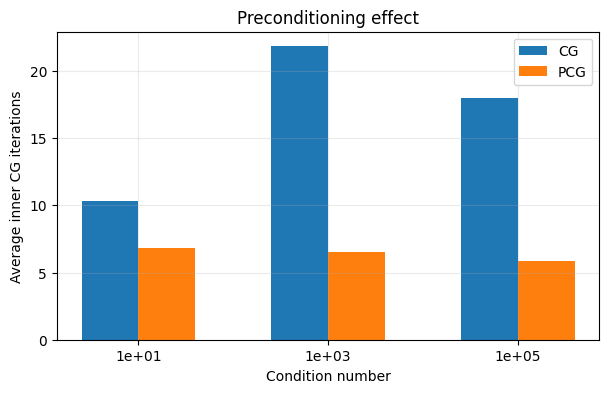

target cond= 10.0 measured hess cond= 10.954 cg avg= 10.333 pcg avg= 6.833
target cond= 1000.0 measured hess cond= 753.44 cg avg= 21.833 pcg avg= 6.5
target cond= 100000.0 measured hess cond= 2453.035 cg avg= 18.0 pcg avg= 5.833


In [10]:
conds=[1e1,1e3,1e5]
avg_cg=[]
avg_pcg=[]
hess_conds=[]

for cond_num in conds:
    _,_,_,_,cg_steps,pcg_steps,hess_cond=run_synthetic(cond_num)
    avg_cg.append(np.mean(cg_steps))
    avg_pcg.append(np.mean(pcg_steps))
    hess_conds.append(hess_cond)

x=np.arange(len(conds))
plt.figure()
plt.bar(x-0.15,avg_cg,width=0.3,label='CG')
plt.bar(x+0.15,avg_pcg,width=0.3,label='PCG')
plt.xticks(x,[f'{c:.0e}' for c in conds])
plt.xlabel('Condition number')
plt.ylabel('Average inner CG iterations')
plt.title('Preconditioning effect')
plt.legend()
plt.show()

for i,c in enumerate(conds):
    print('target cond=',c,'measured hess cond=',round(hess_conds[i],3),'cg avg=',round(avg_cg[i],3),'pcg avg=',round(avg_pcg[i],3))

## 9. Why scalability is needed

Spambase is useful for a clean real-data demonstration, but it has only 57 features. Exact Newton is therefore unusually cheap on this dataset. To fairly show why Newton-CG and PCG matter, we use a synthetic scalability experiment where the feature dimension grows.

## 10. Scalability study

This section is intentionally lighter than a full benchmark so it does not overload the notebook kernel. It still shows the key numerical point: exact Newton becomes more expensive as the feature dimension grows, while Newton-CG and PCG avoid dense Hessian solves.

/var/folders/xx/t73hkxhx7xj95d9rl4spgtb00000gn/T/ipykernel_36347/1975816100.py:9: RuntimeWarning: divide by zero encountered in matmul
  X=Z@(Q*s)
/var/folders/xx/t73hkxhx7xj95d9rl4spgtb00000gn/T/ipykernel_36347/1975816100.py:9: RuntimeWarning: overflow encountered in matmul
  X=Z@(Q*s)
/var/folders/xx/t73hkxhx7xj95d9rl4spgtb00000gn/T/ipykernel_36347/1975816100.py:9: RuntimeWarning: invalid value encountered in matmul
  X=Z@(Q*s)


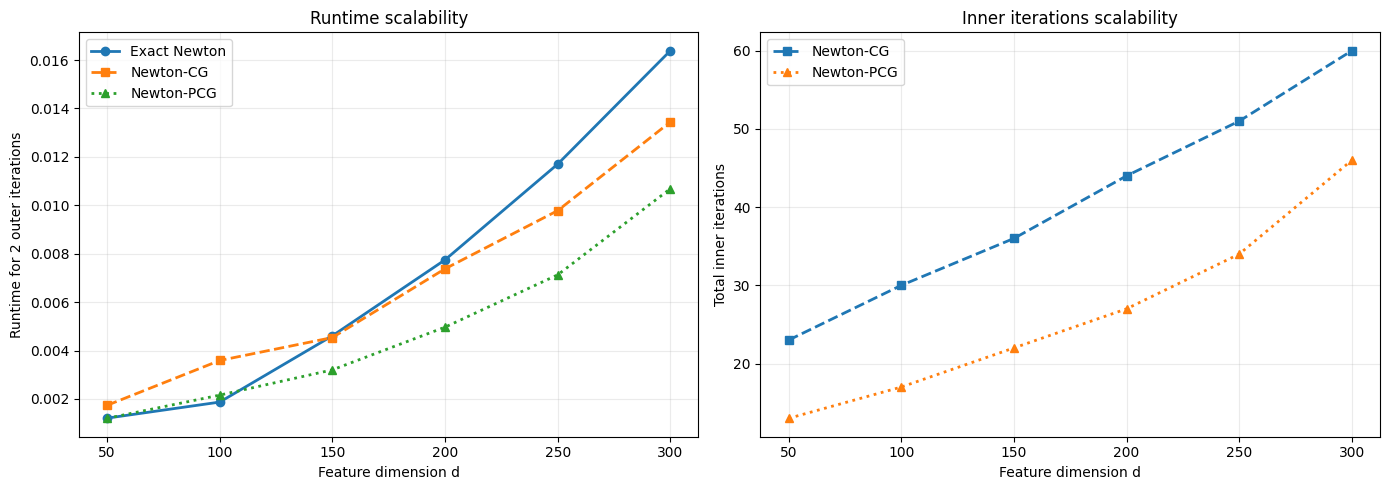

Scalability table
d newton_time cg_time pcg_time cg_iters pcg_iters
50 0.0012 0.0017 0.0012 23 13
100 0.0019 0.0036 0.0022 30 17
150 0.0046 0.0045 0.0032 36 22
200 0.0077 0.0074 0.005 44 27
250 0.0117 0.0098 0.0071 51 34
300 0.0164 0.0134 0.0107 60 46


In [11]:
import time

# local copy so this section can run even if section 7 was skipped
def make_scale_data(n=500,d=40,cond_num=10.0,seed=0):
    rng=np.random.default_rng(seed)
    Z=rng.standard_normal((n,d))
    Q,_=np.linalg.qr(rng.standard_normal((d,d)))
    s=np.geomspace(1.0,cond_num**-0.5,d)
    X=Z@(Q*s)
    w_true=rng.standard_normal(d)/np.sqrt(d)
    score=np.sum(X*w_true,axis=1)+0.1*rng.standard_normal(n)
    y=np.where(score>=0,1.0,-1.0)
    return X,y

n=500
d_list=[50,100,150,200,250,300]
newton_time=[]
cg_time=[]
pcg_time=[]
cg_inner=[]
pcg_inner=[]

for d in d_list:
    X,y=make_scale_data(n=n,d=d,cond_num=10.0,seed=42)
    w0=np.zeros(d)

    start=time.perf_counter()
    newton_method(X,y,w0.copy(),iters=2,use_line_search=True)
    newton_time.append(time.perf_counter()-start)

    start=time.perf_counter()
    _,_,_,steps=newton_cg(X,y,w0.copy(),iters=2,tol=1e-3,max_cg=30,use_line_search=True)
    cg_time.append(time.perf_counter()-start)
    cg_inner.append(sum(steps))

    start=time.perf_counter()
    _,_,_,steps=newton_pcg(X,y,w0.copy(),iters=2,tol=1e-3,max_cg=30,use_line_search=True)
    pcg_time.append(time.perf_counter()-start)
    pcg_inner.append(sum(steps))

fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].plot(d_list,newton_time,marker='o',lw=2,label='Exact Newton')
axes[0].plot(d_list,cg_time,marker='s',ls='--',lw=2,label='Newton-CG')
axes[0].plot(d_list,pcg_time,marker='^',ls=':',lw=2,label='Newton-PCG')
axes[0].set_xlabel('Feature dimension d')
axes[0].set_ylabel('Runtime for 2 outer iterations')
axes[0].set_title('Runtime scalability')
axes[0].legend()

axes[1].plot(d_list,cg_inner,marker='s',ls='--',lw=2,label='Newton-CG')
axes[1].plot(d_list,pcg_inner,marker='^',ls=':',lw=2,label='Newton-PCG')
axes[1].set_xlabel('Feature dimension d')
axes[1].set_ylabel('Total inner iterations')
axes[1].set_title('Inner iterations scalability')
axes[1].legend()
plt.tight_layout()
plt.show()

print('Scalability table')
print('d newton_time cg_time pcg_time cg_iters pcg_iters')
for i,d in enumerate(d_list):
    print(d,round(newton_time[i],4),round(cg_time[i],4),round(pcg_time[i],4),cg_inner[i],pcg_inner[i])

## 11. Hessian spectrum and conditioning

This section directly studies Hessian eigenvalues. This is useful for a numerical analysis report because it connects convergence behavior to conditioning.

/var/folders/xx/t73hkxhx7xj95d9rl4spgtb00000gn/T/ipykernel_36347/4187098453.py:13: RuntimeWarning: divide by zero encountered in matmul
  X=Z@(Q*s)
/var/folders/xx/t73hkxhx7xj95d9rl4spgtb00000gn/T/ipykernel_36347/4187098453.py:13: RuntimeWarning: overflow encountered in matmul
  X=Z@(Q*s)
/var/folders/xx/t73hkxhx7xj95d9rl4spgtb00000gn/T/ipykernel_36347/4187098453.py:13: RuntimeWarning: invalid value encountered in matmul
  X=Z@(Q*s)


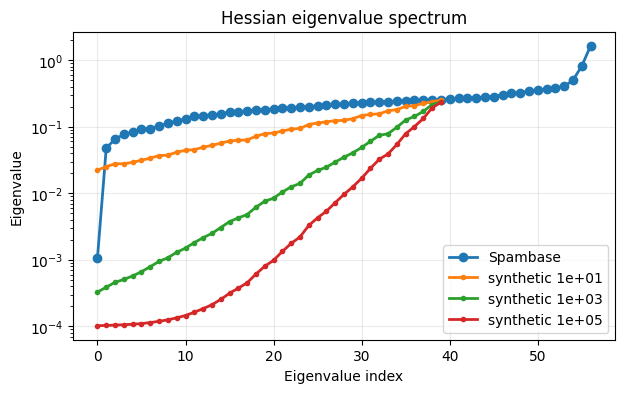

Condition number table
case measured_condition
Spambase 1549.369
synthetic target 10.0 11.369
synthetic target 1000.0 719.211
synthetic target 100000.0 2277.285


In [12]:
def hessian_info(X,y,w,lam=1e-4):
    H=hessian(X,y,w,lam)
    vals=np.linalg.eigvalsh(H)
    cond=vals[-1]/vals[0]
    return vals,cond

# local copy so this section can run independently after setup cells
def make_cond_data(n=1200,d=40,cond_num=1e3,seed=0):
    rng=np.random.default_rng(seed)
    Z=rng.standard_normal((n,d))
    Q,_=np.linalg.qr(rng.standard_normal((d,d)))
    s=np.geomspace(1.0,cond_num**-0.5,d)
    X=Z@(Q*s)
    w_true=rng.standard_normal(d)/np.sqrt(d)
    score=np.sum(X*w_true,axis=1)+0.1*rng.standard_normal(n)
    y=np.where(score>=0,1.0,-1.0)
    return X,y

X,y=load_spambase()
w0=np.zeros(X.shape[1])
vals_spam,cond_spam=hessian_info(X,y,w0)

conds=[1e1,1e3,1e5]
syn_vals=[]
syn_cond=[]
for c in conds:
    Xs,ys=make_cond_data(cond_num=c,seed=1)
    vals,cond=hessian_info(Xs,ys,np.zeros(Xs.shape[1]))
    syn_vals.append(vals)
    syn_cond.append(cond)

plt.figure()
plt.semilogy(vals_spam,marker='o',lw=2,label='Spambase')
for i,c in enumerate(conds):
    plt.semilogy(syn_vals[i],marker='.',lw=2,label=f'synthetic {c:.0e}')
plt.xlabel('Eigenvalue index')
plt.ylabel('Eigenvalue')
plt.title('Hessian eigenvalue spectrum')
plt.legend()
plt.show()

print('Condition number table')
print('case measured_condition')
print('Spambase',round(cond_spam,3))
for i,c in enumerate(conds):
    print('synthetic target',c,round(syn_cond[i],3))

## 12. CG residual decay

Loss curves show outer convergence. Residual curves show what happens inside the linear solver, which is where CG and preconditioning can be compared directly.

/var/folders/xx/t73hkxhx7xj95d9rl4spgtb00000gn/T/ipykernel_36347/4187098453.py:13: RuntimeWarning: divide by zero encountered in matmul
  X=Z@(Q*s)
/var/folders/xx/t73hkxhx7xj95d9rl4spgtb00000gn/T/ipykernel_36347/4187098453.py:13: RuntimeWarning: overflow encountered in matmul
  X=Z@(Q*s)
/var/folders/xx/t73hkxhx7xj95d9rl4spgtb00000gn/T/ipykernel_36347/4187098453.py:13: RuntimeWarning: invalid value encountered in matmul
  X=Z@(Q*s)


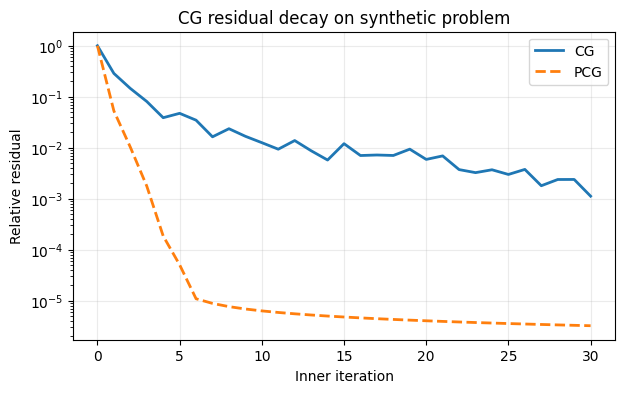

Residual table
method first final
CG 1.0 0.00112539
PCG 1.0 3.25e-06


In [13]:
def cg_residuals(X,y,w,g,lam=1e-4,max_iters=30):
    r=g.copy()
    p=r.copy()
    rr=np.dot(r,r)
    hist=[np.sqrt(rr)]
    for k in range(max_iters):
        Hp=hessian_vector_product(X,y,w,p,lam)
        alpha=rr/(np.dot(p,Hp)+1e-9)
        r=r-alpha*Hp
        rr_new=np.dot(r,r)
        hist.append(np.sqrt(rr_new))
        beta=rr_new/(rr+1e-9)
        p=r+beta*p
        rr=rr_new
    return hist

def pcg_residuals(X,y,w,g,lam=1e-4,max_iters=30):
    r=g.copy()
    M=1.0/(hessian_diagonal(X,y,w,lam)+1e-9)
    z=M*r
    p=z.copy()
    rz=np.dot(r,z)
    hist=[np.linalg.norm(r)]
    for k in range(max_iters):
        Hp=hessian_vector_product(X,y,w,p,lam)
        alpha=rz/(np.dot(p,Hp)+1e-9)
        r=r-alpha*Hp
        hist.append(np.linalg.norm(r))
        z=M*r
        rz_new=np.dot(r,z)
        beta=rz_new/(rz+1e-9)
        p=z+beta*p
        rz=rz_new
    return hist

X,y=make_cond_data(cond_num=1e3,seed=2)
w0=np.zeros(X.shape[1])
g=gradient(X,y,w0)
r1=cg_residuals(X,y,w0,g)
r2=pcg_residuals(X,y,w0,g)
r1=np.array(r1)/r1[0]
r2=np.array(r2)/r2[0]

plt.figure()
plt.semilogy(r1,label='CG',lw=2)
plt.semilogy(r2,label='PCG',lw=2,ls='--')
plt.xlabel('Inner iteration')
plt.ylabel('Relative residual')
plt.title('CG residual decay on synthetic problem')
plt.legend()
plt.show()

print('Residual table')
print('method first final')
print('CG',round(r1[0],4),round(r1[-1],8))
print('PCG',round(r2[0],4),round(r2[-1],8))

## 13. Report-ready result tables

These compact tables can be converted directly into the report's list of tables. They summarize the main numerical evidence without adding another repeated curve.

In [14]:
print('Main method table on Spambase')
print('method final_loss runtime accuracy avg_inner_iters')
for name in ['gd','newton','newton_cg','newton_pcg']:
    f=real_res[name]['losses'][-1]
    t=real_res[name]['times'][-1]
    a=accuracy(real_res['X'],real_res['y'],real_res[name]['w'])
    if 'cg_steps' in real_res[name]:
        inner=np.mean(real_res[name]['cg_steps'])
    else:
        inner=0
    print(name,round(f,6),round(t,4),round(a,4),round(inner,2))

print('')
print('Suggested figures for report')
figs=['Loss vs iteration','Loss vs runtime','Newton family zoom','Sketch size tradeoff','Sketched step quality','Conditioning study','Preconditioning effect','Scalability runtime','CG residual decay','Hessian spectrum']
for i,name in enumerate(figs,1):
    print(i,name)

Main method table on Spambase
method final_loss runtime accuracy avg_inner_iters
gd 0.298669 0.0528 0.9161 0
newton 0.230027 0.0432 0.925 0
newton_cg 0.230036 0.095 0.925 14.08
newton_pcg 0.230027 0.1012 0.925 14.25

Suggested figures for report
1 Loss vs iteration
2 Loss vs runtime
3 Newton family zoom
4 Sketch size tradeoff
5 Sketched step quality
6 Conditioning study
7 Preconditioning effect
8 Scalability runtime
9 CG residual decay
10 Hessian spectrum


## 14. Compact report notes

- On Spambase, GD needs many more iterations than Newton-type methods.
- Newton, Newton-CG, and Newton-PCG are expected to be close on Spambase because the problem dimension is small and the linear solves are accurate.
- Exact Newton may be fastest on Spambase because the Hessian is only $57\times57$. The scalability study explains why Newton-CG and PCG become attractive for larger $d$.
- The line-search and full-step Newton curves can overlap on Spambase because the full Newton step is already stable there.
- Sketch size shows the accuracy-cost tradeoff: larger sketches give more Newton-like behavior but cost more.
- Hessian spectra, condition numbers, and CG residual plots are the most numerical-analysis-focused evidence in the notebook.
- For the report structure, these notebook outputs can support the List of Figures, List of Tables, Summary, Conclusion, and References sections.